<a href="https://colab.research.google.com/github/pronabpaul/medimg-spectral-analysis/blob/main/spectral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modality-Aware Frequency and Texture Characterisation of Medical Imaging Datasets

**Pronab Kumar Paul**

This study quantifies modality-specific differences between OrganSMNIST and PathMNIST using Fourier spectral analysis, multi-scale Local Binary Patterns (LBP), and Gray-Level Co-occurrence Matrix (GLCM) statistics. It aims to characterise differences in frequency content and texture between these datasets and to provide empirical evidence supporting modality-aware representation learning in medical image analysis.

## 1. Problem Statement

Medical imaging datasets exhibit substantial variation in frequency content, texture, and colour characteristics. Despite this, deep learning pipelines frequently employ similar architectural and preprocessing strategies across heterogeneous imaging modalities, often overlooking these underlying statistical differences.

This study investigates modality-specific image properties through spectral analysis, multi-scale texture descriptors, and second-order statistical measures using OrganSMNIST and PathMNIST. The objective is to quantify frequency and texture differences between the two datasets and to explore how such differences may inform modality-aware representation learning and architecture design in medical image analysis.

Overall, this work provides a unified, interpretable statistical framework for comparing medical imaging modalities using classical frequency and texture descriptors, highlighting measurable structural differences that are often ignored in standard deep learning pipelines.

## 2. Background & Related Work

Natural images exhibit well-documented statistical regularities in the frequency domain. Early work by Field (1987) demonstrated that the power spectra of natural scenes approximately follow a power-law decay of the form 1/f<sup>α</sup>, reflecting scale-invariant structure and long-range spatial correlations. These properties have been extensively studied in vision science, image compression, and representation learning, and are often used as a baseline for characterising natural image statistics.

Classical texture descriptors such as Local Binary Patterns (LBP) and Gray-Level Co-occurrence Matrices (GLCM) remain widely used in medical image analysis. LBP captures local micro-texture through neighbourhood intensity comparisons, whereas GLCM models second-order spatial dependencies, including contrast, homogeneity, energy, and correlation. Despite advances in deep learning, these descriptors remain relevant due to their interpretability, computational efficiency, and robustness in low-data regimes.

The MedMNIST benchmark, introduced by Yang et al. (2023), provides a standardised collection of lightweight biomedical image datasets spanning multiple imaging modalities and diagnostic tasks. It enables reproducible benchmarking using uniformly resized 28×28 inputs, facilitating controlled cross-dataset comparisons.

Recent studies have investigated robustness, representation learning, and modality-aware behaviour within MedMNIST, including corruption robustness and evaluations of foundation models. However, relatively little work has systematically analysed spectral and texture statistics across heterogeneous medical imaging datasets within a unified analytical framework.

In particular, prior work has not jointly examined:

- frequency-domain decay characteristics
- multi-scale texture statistics
- colour-channel-specific texture variation
- intra-class variability patterns

across CT-like anatomical images and histopathology images within the MedMNIST framework.

This study addresses this gap by combining:

- Fourier spectral analysis with power-law slope estimation
- multi-scale Local Binary Pattern analysis
- multi-directional, multi-distance Gray-Level Co-occurrence Matrix analysis

to provide a unified modality-aware characterisation of OrganSMNIST and PathMNIST.

## 3. Hypotheses

| ID | Hypothesis |
|----|------------|
| H1 | OrganSMNIST exhibits a significantly higher spectral slope (α) than PathMNIST, indicating faster decay of high‑frequency components. |
| H2 | PathMNIST exhibits higher GLCM contrast and lower homogeneity and energy compared to OrganSMNIST, reflecting more complex local texture structure. |
| H3 | In PathMNIST, GLCM feature distributions differ significantly across RGB channels, indicating colour-dependent texture variation. |
| H4 | Spectral slope (α) varies significantly across organ classes within OrganSMNIST, indicating intra-modality heterogeneity. |
| H5 | Increasing levels of Gaussian noise lead to a statistically significant reduction in spectral slope (α), with a stronger effect observed in OrganSMNIST than in PathMNIST. |

## 4. Objectives

This study aims to characterise modality-specific differences between OrganSMNIST and PathMNIST through complementary spectral, texture, and statistical analyses.

The specific objectives are as follows:

- Quantify frequency-domain decay characteristics using FFT-based power-law fitting.
- Characterise local texture structure using multi-scale Local Binary Patterns (LBP) and multi-distance Gray-Level Co-occurrence Matrices (GLCM).
- Assess the influence of colour representation by analysing channel-wise variations in PathMNIST.
- Analyse intra-modality variability through class-wise spectral slope distributions.
- Evaluate robustness of spectral statistics under Gaussian noise perturbations.
- Investigate feature separability using dimensionality reduction (t-SNE) as an exploratory analysis.
- Examine feature importance patterns using Random Forest classifiers as an exploratory analysis.

## 5. Datasets

| Dataset | Modality | Classes | Size | Colour | Samples |
|---------|----------|---------|------|--------|---------|
| OrganSMNIST | CT-like anatomical slices | 11 organs | 28×28 | Grayscale | 500 |
| PathMNIST | Histopathology | 9 pathologies | 28×28 | RGB | 500 |

All images are originally provided at a resolution of 28×28 pixels. To enable frequency-domain analysis, images are upsampled to 128×128 using bicubic interpolation for FFT-based spectral estimation. This step improves the stability of radial frequency estimation by reducing discretisation effects, although it does not introduce new semantic information.

For GLCM-based texture analysis, images are resized to 64×64 using nearest-neighbour interpolation. This choice preserves discrete intensity structure required for co-occurrence statistics while maintaining computational efficiency.

These preprocessing steps are applied consistently across both datasets to ensure fair cross-modality comparison under a unified experimental pipeline.

## 6. Methodology

The proposed analysis focuses on three complementary families of handcrafted descriptors: frequency-domain statistics (Fourier spectrum), local texture encoding (Local Binary Patterns, LBP), and second-order spatial dependencies (Gray-Level Co-occurrence Matrices, GLCM). These descriptors capture global scale-invariant frequency behaviour, local micro-texture patterns, and pairwise pixel intensity relationships respectively. Rather than aiming for exhaustive feature coverage, the objective is to construct a minimal and interpretable set of statistical descriptors for modality-aware comparison in medical imaging.

### 6.1 Datasets and Sampling

We use OrganSMNIST (CT-derived anatomical slices, 11 classes, grayscale) and PathMNIST (histopathology patches, 9 classes, RGB) from MedMNIST v3. To mitigate class imbalance, we perform stratified sampling of 500 images per dataset. All images are resized to 128×128 using bicubic interpolation for spectral analysis, while GLCM computation uses a separate 64×64 resolution to balance computational efficiency and quantisation stability.

### 6.2 Preprocessing

All images are normalised to zero mean and unit variance on a per-image basis (per channel for RGB data). No additional denoising, histogram equalisation, or contrast enhancement is applied, ensuring that measured statistics reflect intrinsic dataset properties.

### 6.3 Fourier Spectral Analysis (FFT)

We compute the 2D fast Fourier transform and shift the zero-frequency component to the centre. The radial power spectrum is obtained by averaging squared magnitude values over concentric frequency bands. Radial averaging assumes approximate isotropy of frequency statistics, a common and acceptable simplification for aggregated modality-level comparison.

The power-law exponent α, defined by P(f) ∝ f<sup>-α</sup>, is estimated via robust RANSAC regression in log-log space, using frequencies up to 80% of the Nyquist limit to avoid high-frequency noise domination. For RGB images, spectral analysis is performed per channel and then averaged to obtain a single modality-level descriptor.

### 6.4 Local Binary Patterns (LBP)

Multi-scale uniform LBP is computed using radii {1, 2, 3} with corresponding neighbour counts {8, 16, 24}. For each image, histograms of uniform patterns are computed and concatenated into a single feature vector. RGB images are converted to grayscale to ensure consistent luminance-based texture representation and to avoid redundancy across colour channels in local micro-texture encoding.

### 6.5 Gray-Level Co-occurrence Matrices (GLCM)

Each image is quantised to 8 intensity levels using min-max normalisation. GLCMs are computed over distances {1, 2, 4} and angles {0°, 45°, 90°, 135°}. We extract contrast, homogeneity, energy, and correlation, and average over all distances and angles. For RGB images, features are computed per channel and concatenated, resulting in a fixed-dimensional representation. Additional experiments are conducted in HSV and LAB colour spaces for sensitivity analysis.

For cross‑dataset comparisons, all analyses are performed within consistent feature spaces: grayscale‑to‑grayscale (OrganSMNIST vs PathMNIST grayscale) and RGB‑to‑RGB (colour channel experiments). Cross‑colour‑space experiments (HSV, LAB) are treated as separate ablations and are not directly combined with grayscale results. All reported statistical comparisons are performed within a single consistent feature space per experiment, and no cross-space concatenation is performed across colour representations.

### 6.6 Colour Channel Analysis (PathMNIST)

To evaluate colour dependency, GLCM feature distributions across RGB channels are compared using Kruskal-Wallis tests. This assesses whether texture statistics vary significantly across colour channels in histopathology images.

### 6.7 Intra-class Variability

Spectral slope α is computed per image and grouped by anatomical class in OrganSMNIST. A Kruskal-Wallis test is used to assess whether frequency decay characteristics differ significantly across organ categories.

### 6.8 Noise Robustness

Gaussian noise with σ ∈ {0.05, 0.1, 0.15} is added in the normalised intensity space (zero mean, unit variance). For reference, these correspond approximately to σ = 5, 10, 15 in the unnormalised pixel intensity scale, although all experiments are performed in the standardised (zero‑mean, unit‑variance) space. Spectral slope α is recomputed for perturbed images, and robustness is quantified using Spearman correlation and changes in mean α relative to clean images. Lower correlation and larger deviations indicate higher sensitivity to noise.

### 6.9 Statistical Testing

Pairwise comparisons between OrganSMNIST and PathMNIST use the Mann-Whitney U test. Multi-group comparisons use the Kruskal-Wallis test. Effect sizes are reported using Cliff’s delta. Bonferroni correction is applied for multiple comparisons where appropriate (LBP bins and GLCM metrics). A significance threshold of α = 0.05 is used unless otherwise stated.

### 6.10 Feature Analysis and Visualisation (Exploratory)

For exploratory analysis, each image is represented by a concatenation of spectral slope α, LBP features, and GLCM features. To ensure comparability, PathMNIST RGB images are converted to grayscale for joint embedding. After standardisation, t-SNE is applied to visualise modality separability. A Random Forest classifier is trained to distinguish datasets, and feature importance scores are used to estimate the relative contribution of each descriptor family.

### 6.11 Reproducibility

All experiments use a fixed random seed (42) for reproducibility. This seed controls stratified sampling, noise injection, and stochastic components in feature computation (e.g., RANSAC sampling) and model training where applicable (e.g., Random Forest). t-SNE uses a fixed initialisation for reproducibility. Stratified sampling ensures balanced class representation. Library versions are recorded, and the entire pipeline is implemented in a self-contained notebook environment.

In [34]:
# ============================================================
# 0. Setup & Reproducibility
# ============================================================

# The following pip command may show dependency resolver warnings
# (e.g., numpy version conflicts). These are harmless because the
# conflicting packages are not used in this notebook.

!pip install -q --upgrade medmnist scikit-image scipy umap-learn

# ------------------------------------------------------------
# Standard library imports
# ------------------------------------------------------------

import sys
import time
import platform
import warnings

# ------------------------------------------------------------
# Scientific computing
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Signal processing & statistics
# ------------------------------------------------------------

from scipy.fft import fft2, fftshift
from scipy.stats import mannwhitneyu, kruskal, spearmanr

# ------------------------------------------------------------
# Machine learning & dimensionality reduction
# ------------------------------------------------------------

from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Image processing
# ------------------------------------------------------------

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.transform import resize

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

import medmnist
from medmnist import OrganSMNIST, PathMNIST

# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

from tqdm import tqdm

# ============================================================
# Cliff's delta effect size
# ============================================================

def cliffs_delta(x, y):
    """Non‑parametric effect size measure. Returns value in [-1, 1]."""
    nx, ny = len(x), len(y)
    r = 0
    for xi in x:
        for yj in y:
            if xi > yj:
                r += 1
            elif xi < yj:
                r -= 1
    return r / (nx * ny)

# ============================================================
# Reproducibility
# ============================================================

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning, module="skimage")

# ============================================================
# Visualization settings
# ============================================================

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# ============================================================
# Environment information
# ============================================================

print("=" * 60)
print("Environment Information")
print("=" * 60)

print(f"Random seed       : {SEED}")
print(f"Python version    : {sys.version.split()[0]}")
print(f"Platform          : {platform.platform()}")
print(f"NumPy version     : {np.__version__}")
print(f"Pandas version    : {pd.__version__}")
print(f"MedMNIST version  : {medmnist.__version__}")

print("=" * 60)

# ============================================================
# Runtime tracking
# ============================================================

start_time = time.time()

Environment Information
Random seed       : 42
Python version    : 3.12.13
Platform          : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy version     : 2.0.2
Pandas version    : 2.2.2
MedMNIST version  : 3.0.2


In [35]:
# ============================================================
# 1. Data Loading
# ============================================================

N_SAMPLES = 500
TARGET_SIZE = 128

# ------------------------------------------------------------
# Load MedMNIST datasets
# ------------------------------------------------------------

print("Loading OrganSMNIST...")
organ_dataset = OrganSMNIST(split='train', download=True)

print("Loading PathMNIST...")
path_dataset = PathMNIST(split='train', download=True)

# ------------------------------------------------------------
# Helper: extract scalar integer labels
# ------------------------------------------------------------

def get_scalar_labels(dataset):
    """
    Extract integer labels from MedMNIST datasets.
    MedMNIST v3 returns labels as numpy.int64.
    """
    labels = []
    for i in tqdm(range(len(dataset)), desc="Extracting labels"):
        lbl = dataset[i][1]
        labels.append(int(lbl))
    return labels

# ------------------------------------------------------------
# Extract labels
# ------------------------------------------------------------

print("\nExtracting labels from OrganSMNIST...")
organ_labels = get_scalar_labels(organ_dataset)

print("Extracting labels from PathMNIST...")
path_labels = get_scalar_labels(path_dataset)

# ------------------------------------------------------------
# Dataset summary
# ------------------------------------------------------------

organ_sample, _ = organ_dataset[0]
path_sample, _ = path_dataset[0]

print("\n" + "=" * 60)
print("Dataset Summary")
print("=" * 60)

print(f"OrganSMNIST : {len(organ_labels):,} images | "
      f"{len(np.unique(organ_labels))} classes | "
      f"Image size: {np.array(organ_sample).shape}")

print(f"PathMNIST   : {len(path_labels):,} images | "
      f"{len(np.unique(path_labels))} classes | "
      f"Image size: {np.array(path_sample).shape}")

print("=" * 60)

Loading OrganSMNIST...
Loading PathMNIST...

Extracting labels from OrganSMNIST...


Extracting labels: 100%|██████████| 13932/13932 [00:00<00:00, 31685.39it/s]


Extracting labels from PathMNIST...


Extracting labels: 100%|██████████| 89996/89996 [00:04<00:00, 21828.55it/s]


Dataset Summary
OrganSMNIST : 13,932 images | 11 classes | Image size: (28, 28)
PathMNIST   : 89,996 images | 9 classes | Image size: (28, 28, 3)


In [37]:
# ============================================================
# 2. Stratified Sampling
# ============================================================

def stratified_sample(dataset, labels, n_samples, seed=42):
    """
    Perform approximately balanced stratified sampling.

    Returns:
        imgs  : sampled images
        lbls  : corresponding labels
    """

    rng = np.random.default_rng(seed)

    unique_classes = np.unique(labels)

    base_per_class = n_samples // len(unique_classes)

    remainder = n_samples % len(unique_classes)

    # --------------------------------------------------------
    # Build class index mapping
    # --------------------------------------------------------

    class_to_indices = {
        cls: np.where(np.array(labels) == cls)[0]
        for cls in unique_classes
    }

    sampled_indices = []

    # --------------------------------------------------------
    # Balanced sampling
    # --------------------------------------------------------

    for i, cls in enumerate(unique_classes):

        n_take = base_per_class + (1 if i < remainder else 0)

        cls_indices = class_to_indices[cls]

        # For MedMNIST, each class has more than n_take samples,
        # so replace=False is safe.
        chosen = rng.choice(
            cls_indices,
            size=n_take,
            replace=False
        )

        sampled_indices.extend(chosen.tolist())

    rng.shuffle(sampled_indices)

    # --------------------------------------------------------
    # Extract images and labels
    # --------------------------------------------------------

    imgs = [dataset[i][0] for i in sampled_indices]

    lbls = [labels[i] for i in sampled_indices]

    return imgs, lbls

# ------------------------------------------------------------
# Perform sampling
# ------------------------------------------------------------

organ_imgs_raw, organ_lbls = stratified_sample(
    organ_dataset,
    organ_labels,
    N_SAMPLES,
    seed=SEED
)

path_imgs_raw, path_lbls = stratified_sample(
    path_dataset,
    path_labels,
    N_SAMPLES,
    seed=SEED
)

# ------------------------------------------------------------
# Verify sampling
# ------------------------------------------------------------

print("\nSampling Summary")
print("-" * 50)

print(f"OrganSMNIST sampled : {len(organ_imgs_raw)} images")
print("Class distribution:", np.bincount(organ_lbls))

print()
print(f"PathMNIST sampled   : {len(path_imgs_raw)} images")
print("Class distribution:", np.bincount(path_lbls))


Sampling Summary
--------------------------------------------------
OrganSMNIST sampled : 500 images
Class distribution: [46 46 46 46 46 45 45 45 45 45 45]

PathMNIST sampled   : 500 images
Class distribution: [56 56 56 56 56 55 55 55 55]


In [38]:
# ============================================================
# 3. Preprocessing
# ============================================================

def preprocess_image(
    img,
    target_size=128,
    is_rgb=False,
    normalize=True
):
    """
    Resize image and optionally apply per-image normalization.

    Parameters
    ----------
    img : PIL image or ndarray
        Input image.

    target_size : int
        Target spatial resolution.

    is_rgb : bool
        Whether image contains RGB channels.

    normalize : bool
        Apply zero-mean, unit-variance normalization.

    Returns
    -------
    ndarray
        Preprocessed image.
    """

    img = np.array(img).astype(np.float32)

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    if is_rgb:

        if img.shape[:2] != (target_size, target_size):

            img = resize(
                img,
                (target_size, target_size, 3),
                order=3,
                preserve_range=True,
                anti_aliasing=False
            ).astype(np.float32)

        # ----------------------------------------------------
        # Per-channel normalization
        # ----------------------------------------------------

        if normalize:

            for c in range(3):

                img[..., c] = (
                    img[..., c] - img[..., c].mean()
                ) / (
                    img[..., c].std() + 1e-8
                )

    else:

        img = img.squeeze()

        if img.shape != (target_size, target_size):

            img = resize(
                img,
                (target_size, target_size),
                order=3,
                preserve_range=True,
                anti_aliasing=False
            ).astype(np.float32)

        # ----------------------------------------------------
        # Grayscale normalization
        # ----------------------------------------------------

        if normalize:

            img = (
                img - img.mean()
            ) / (
                img.std() + 1e-8
            )

    return img

# ------------------------------------------------------------
# Preprocess datasets
# ------------------------------------------------------------

organ_imgs = [
    preprocess_image(
        img,
        target_size=TARGET_SIZE,
        is_rgb=False,
        normalize=True
    )
    for img in tqdm(organ_imgs_raw, desc="Organ preprocessing")
]

path_imgs = [
    preprocess_image(
        img,
        target_size=TARGET_SIZE,
        is_rgb=True,
        normalize=True
    )
    for img in tqdm(path_imgs_raw, desc="Path preprocessing")
]

# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

print("\nPreprocessing Summary")
print("-" * 50)

print(f"OrganSMNIST image shape : {organ_imgs[0].shape}")
print(f"PathMNIST image shape   : {path_imgs[0].shape}")

Path preprocessing: 100%|██████████| 500/500 [00:41<00:00, 12.15it/s]


Preprocessing Summary
--------------------------------------------------
OrganSMNIST image shape : (128, 128)
PathMNIST image shape   : (128, 128, 3)



Computing spectral slopes α...


FFT: 100%|██████████| 500/500 [00:51<00:00,  9.80it/s]



H1: Spectral Slope (α) Comparison

Descriptive Statistics:
--------------------------------------------------
Dataset         Mean α       Std α       
--------------------------------------------------
OrganSMNIST     3.3841       ± 0.2025
PathMNIST       3.2869       ± 0.1916

Inferential Statistics:
--------------------------------------------------
Mann-Whitney U        : 160241.0
p-value               : 1.1915e-14 *
Significant at α=0.05 : Yes
Cliff's delta (effect): 0.282 (small)

Interpretation:
--------------------------------------------------
OrganSMNIST has steeper spectral slope (α) than PathMNIST (δ = 0.282).
The difference is statistically significant (p < 0.05).

Figure 1: Distribution of Spectral Slope α by Dataset


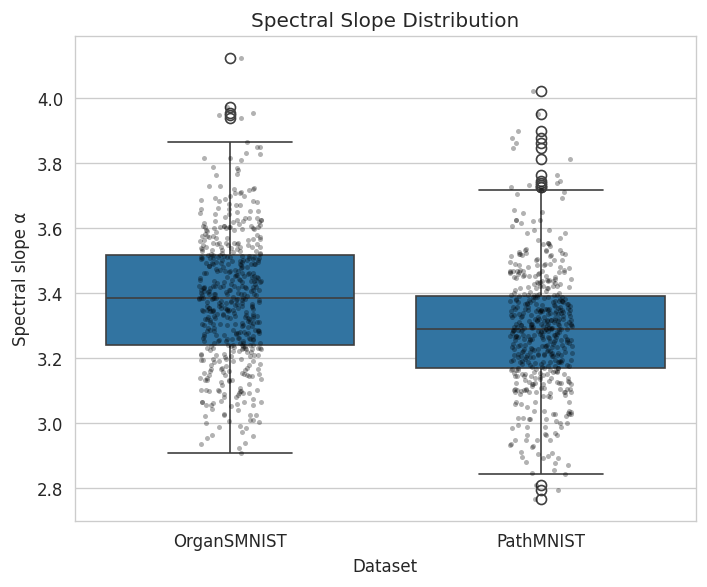


Figure 2: Mean Radial Power Spectrum (Log-Log Scale)


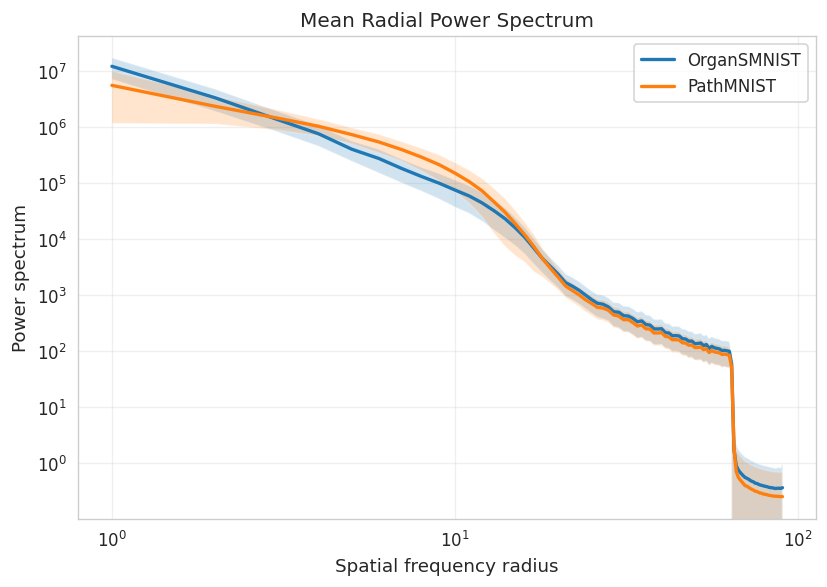


Figure 3: Example Power-Law Fit (Single OrganSMNIST Image)


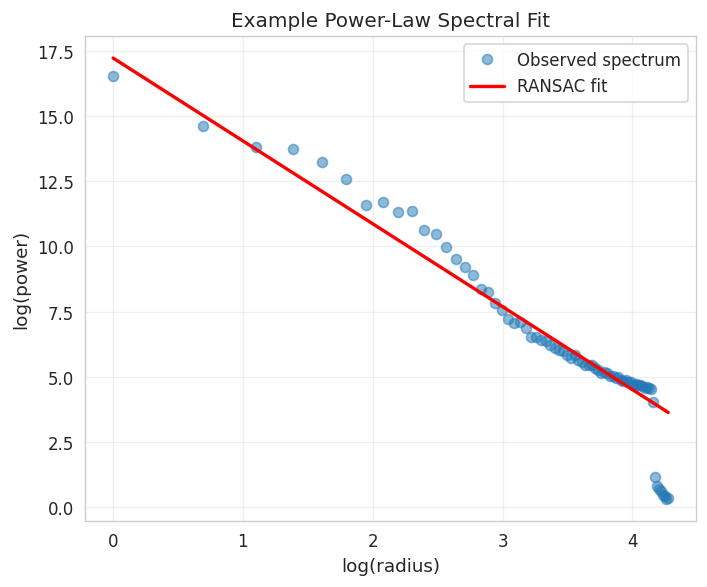

In [40]:
# ============================================================
# 4. FFT Radial Profile & Robust Power-Law Fit
# ============================================================

from sklearn.linear_model import RANSACRegressor

def radial_profile(power_spectrum):
    """
    Compute radially averaged power spectrum.
    """
    center = np.array(power_spectrum.shape) // 2
    y, x = np.indices(power_spectrum.shape)
    r = np.hypot(x - center[1], y - center[0]).astype(int)
    sums = np.bincount(r.ravel(), power_spectrum.ravel())
    counts = np.bincount(r.ravel())
    radial = sums / np.maximum(counts, 1)
    return radial[1:]  # exclude DC component


def fit_power_law_ransac(radial, max_frac=0.8):
    """Robust power‑law fit using RANSAC."""
    max_r = max(int(len(radial) * max_frac), 5)
    radii = np.arange(1, max_r + 1)
    log_r = np.log(radii).reshape(-1, 1)
    log_p = np.log(radial[:max_r] + 1e-8)
    ransac = RANSACRegressor(random_state=SEED, min_samples=0.5, residual_threshold=0.5)
    ransac.fit(log_r, log_p)
    alpha = -ransac.estimator_.coef_[0]
    return alpha


def compute_fft_features(imgs, is_rgb=False):
    """Compute spectral slope α and radial profiles."""
    alphas = []
    radial_profiles = []
    for img in tqdm(imgs, desc="FFT"):
        if is_rgb:
            radials = []
            for c in range(3):
                f = fft2(img[..., c])
                fshift = fftshift(f)
                power = np.abs(fshift) ** 2
                radials.append(radial_profile(power))
            min_len = min(len(r) for r in radials)
            radial_avg = np.mean([r[:min_len] for r in radials], axis=0)
        else:
            f = fft2(img)
            fshift = fftshift(f)
            power = np.abs(fshift) ** 2
            radial_avg = radial_profile(power)
        alpha = fit_power_law_ransac(radial_avg)
        alphas.append(alpha)
        radial_profiles.append(radial_avg)
    return np.array(alphas), radial_profiles


# ============================================================
# Compute FFT Features
# ============================================================

print("\nComputing spectral slopes α...")
organ_alphas, organ_radials = compute_fft_features(organ_imgs, is_rgb=False)
path_alphas, path_radials = compute_fft_features(path_imgs, is_rgb=True)


# ============================================================
# Statistical Comparison (H1) – Professional Output
# ============================================================

print("\n" + "=" * 70)
print("H1: Spectral Slope (α) Comparison")
print("=" * 70)

# Summary statistics
organ_mean = np.mean(organ_alphas)
organ_std = np.std(organ_alphas)
path_mean = np.mean(path_alphas)
path_std = np.std(path_alphas)

# Mann‑Whitney U test
u_stat, p_val = mannwhitneyu(organ_alphas, path_alphas, alternative='two-sided')
significant = p_val < 0.05

# Cliff’s delta effect size
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    greater = sum(np.sum(xi > y) for xi in x)
    lower = sum(np.sum(xi < y) for xi in x)
    return (greater - lower) / (nx * ny)

delta = cliffs_delta(organ_alphas, path_alphas)

if abs(delta) < 0.147:
    effect = "negligible"
elif abs(delta) < 0.33:
    effect = "small"
elif abs(delta) < 0.474:
    effect = "medium"
else:
    effect = "large"

print("\nDescriptive Statistics:")
print("-" * 50)
print(f"{'Dataset':<15} {'Mean α':<12} {'Std α':<12}")
print("-" * 50)
print(f"{'OrganSMNIST':<15} {organ_mean:.4f}       ± {organ_std:.4f}")
print(f"{'PathMNIST':<15} {path_mean:.4f}       ± {path_std:.4f}")

print("\nInferential Statistics:")
print("-" * 50)
print(f"Mann-Whitney U        : {u_stat:.1f}")
print(f"p-value               : {p_val:.4e} {'*' if significant else 'ns'}")
print(f"Significant at α=0.05 : {'Yes' if significant else 'No'}")
print(f"Cliff's delta (effect): {delta:.3f} ({effect})")

print("\nInterpretation:")
print("-" * 50)
if delta > 0:
    print(f"OrganSMNIST has steeper spectral slope (α) than PathMNIST (δ = {delta:.3f}).")
else:
    print(f"PathMNIST has steeper spectral slope (δ = {delta:.3f}).")
if significant:
    print("The difference is statistically significant (p < 0.05).")
else:
    print("The difference is not statistically significant (p ≥ 0.05).")
print("=" * 70)


# ============================================================
# Figure 1: Boxplot of Spectral Slopes
# ============================================================

print("\n" + "=" * 70)
print("Figure 1: Distribution of Spectral Slope α by Dataset")
print("=" * 70)

df_alpha = pd.DataFrame({
    "Alpha": np.concatenate([organ_alphas, path_alphas]),
    "Dataset": (["OrganSMNIST"] * len(organ_alphas) + ["PathMNIST"] * len(path_alphas))
})

plt.figure(figsize=(6, 5))
sns.boxplot(data=df_alpha, x="Dataset", y="Alpha")
sns.stripplot(data=df_alpha, x="Dataset", y="Alpha", alpha=0.3, size=3, color="black")
plt.title("Spectral Slope Distribution", fontsize=12)
plt.ylabel("Spectral slope α")
plt.tight_layout()
plt.show()

# Add a blank line for visual separation
print()


# ============================================================
# Figure 2: Mean Radial Power Spectrum
# ============================================================

print("=" * 70)
print("Figure 2: Mean Radial Power Spectrum (Log-Log Scale)")
print("=" * 70)

# Compute mean radial profiles
min_len = min(len(organ_radials[0]), len(path_radials[0]))
organ_trimmed = np.array([r[:min_len] for r in organ_radials])
path_trimmed = np.array([r[:min_len] for r in path_radials])
organ_mean_radial = organ_trimmed.mean(axis=0)
organ_std_radial = organ_trimmed.std(axis=0)
path_mean_radial = path_trimmed.mean(axis=0)
path_std_radial = path_trimmed.std(axis=0)
radii = np.arange(1, min_len + 1)

plt.figure(figsize=(7, 5))
plt.plot(radii, organ_mean_radial, linewidth=2, label="OrganSMNIST")
plt.fill_between(radii, organ_mean_radial - organ_std_radial, organ_mean_radial + organ_std_radial, alpha=0.2)
plt.plot(radii, path_mean_radial, linewidth=2, label="PathMNIST")
plt.fill_between(radii, path_mean_radial - path_std_radial, path_mean_radial + path_std_radial, alpha=0.2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Spatial frequency radius", fontsize=11)
plt.ylabel("Power spectrum", fontsize=11)
plt.title("Mean Radial Power Spectrum", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print()


# ============================================================
# Figure 3: Example Log-Log Fit with RANSAC
# ============================================================

print("=" * 70)
print("Figure 3: Example Power-Law Fit (Single OrganSMNIST Image)")
print("=" * 70)

example_radial = organ_radials[0]
max_r = max(int(len(example_radial) * 0.8), 5)
radii_fit = np.arange(1, max_r + 1)
log_r = np.log(radii_fit)
log_p = np.log(example_radial[:max_r] + 1e-8)

ransac = RANSACRegressor(random_state=SEED, min_samples=0.5, residual_threshold=0.5)
ransac.fit(log_r.reshape(-1, 1), log_p)
pred = ransac.predict(log_r.reshape(-1, 1))

plt.figure(figsize=(6, 5))
plt.plot(log_r, log_p, 'o', alpha=0.5, label="Observed spectrum")
plt.plot(log_r, pred, linewidth=2, label="RANSAC fit", color="red")
plt.xlabel("log(radius)", fontsize=11)
plt.ylabel("log(power)", fontsize=11)
plt.title("Example Power-Law Spectral Fit", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print()

**Result H1:** The spectral slope α differs significantly between OrganSMNIST (α = 3.384 ± 0.202) and PathMNIST (α = 3.287 ± 0.192) (Mann‑Whitney U, p = 1.19 × 10⁻¹⁴). OrganSMNIST exhibits a higher mean α, indicating faster power decay with increasing spatial frequency. The effect size (Cliff’s delta = 0.282, small) confirms a consistent but modest separation between the two modalities.

**Interpretation:** A higher spectral slope reflects greater dominance of low‑frequency components. In OrganSMNIST (CT‑derived anatomical slices), this is consistent with larger homogeneous regions and smoother structural transitions. In contrast, PathMNIST retains relatively higher energy at mid‑to‑high frequencies, characteristic of the fine‑grained, irregular textures found in histopathology patches. The small effect size suggests substantial overlap in global frequency statistics, likely influenced by the low native resolution (28×28) and subsequent upsampling. Nevertheless, the statistically significant difference supports **H1**, confirming modality‑dependent variation in spectral decay characteristics.


Computing multi-scale LBP features...


LBP: 100%|██████████| 500/500 [00:15<00:00, 32.85it/s]



LBP feature shape:
OrganSMNIST: (500, 54)
PathMNIST:   (500, 54)

Multi-Scale LBP Statistical Comparison (Exploratory)
Significant bins: 43/54
Bonferroni α = 0.000926

Jensen-Shannon divergence = 0.1289


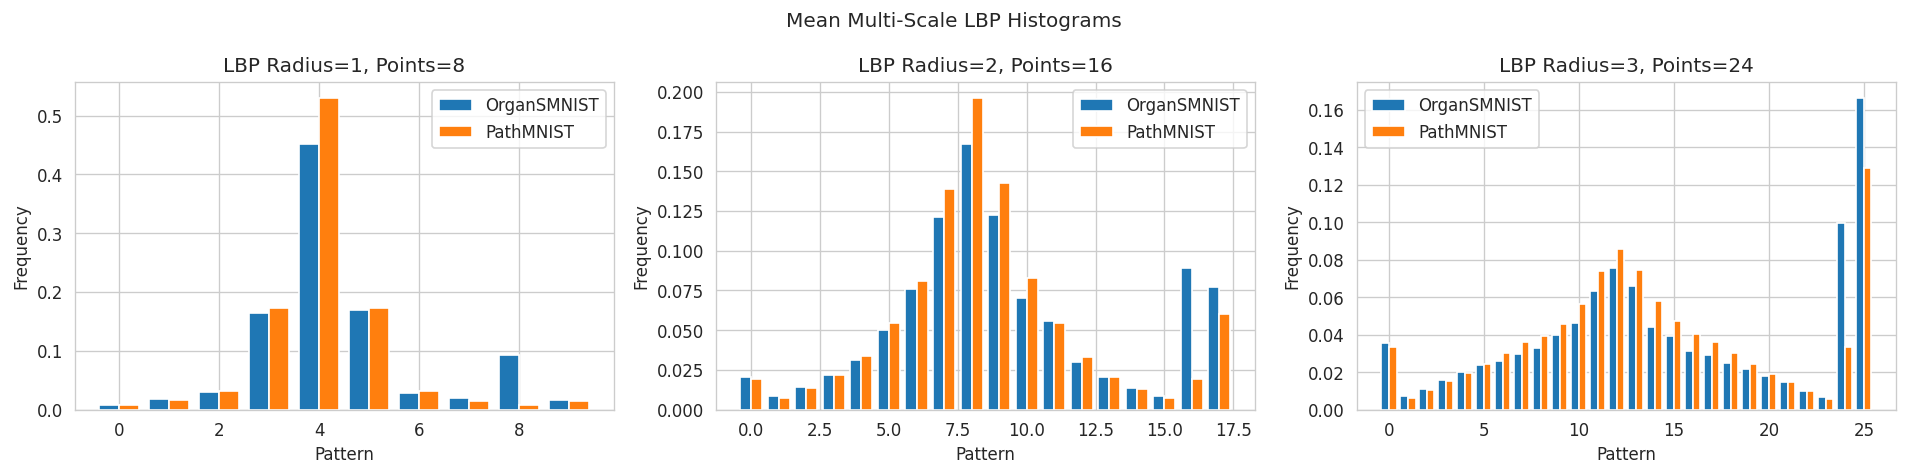

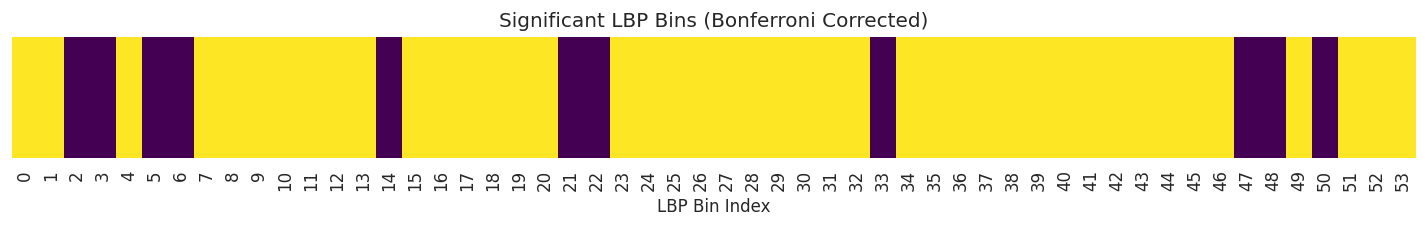


Computing t-SNE visualization...


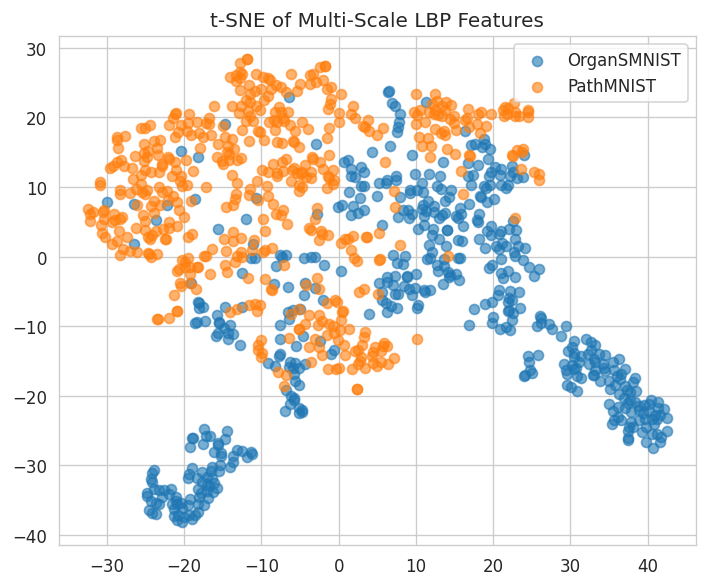


Training Random Forest (exploratory)...


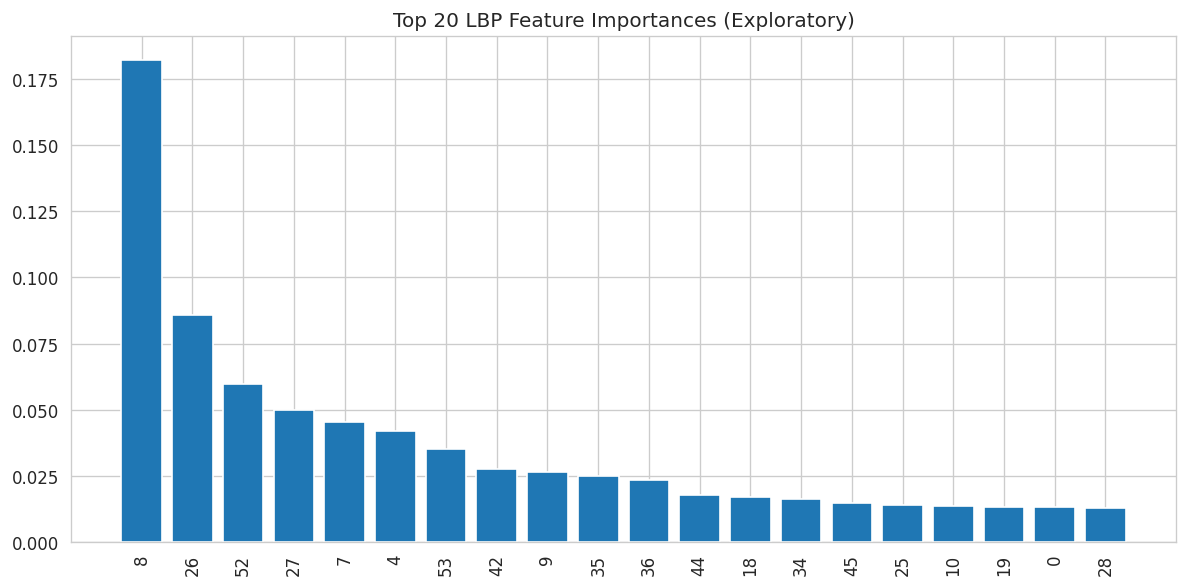


LBP ANALYSIS SUMMARY
Bins: 54
Significant bins: 43
JS divergence: 0.1289
Moderate texture differences.


In [41]:
# ============================================================
# 5. Multi-Scale Local Binary Patterns (LBP)
# ============================================================

LBP_RADII = [1, 2, 3]
LBP_POINTS = [8, 16, 24]

from scipy.spatial.distance import jensenshannon

# ------------------------------------------------------------
# LBP Feature Extraction
# ------------------------------------------------------------

def lbp_features(imgs, radii, points, is_rgb=False):
    """
    Compute concatenated multi-scale LBP histograms.
    """

    features = []

    for img in tqdm(imgs, desc="LBP"):

        # ----------------------------
        # RGB → grayscale conversion
        # ----------------------------
        if is_rgb:
            img = np.array(img, dtype=np.float32)

            gray = np.dot(
                img[..., :3],
                [0.299, 0.587, 0.114]
            )
        else:
            gray = np.array(img, dtype=np.float32)

        hist_list = []

        # ----------------------------
        # Multi-scale LBP
        # ----------------------------
        for r, n in zip(radii, points):

            lbp = local_binary_pattern(
                gray,
                P=n,
                R=r,
                method='uniform'
            )

            # Correct number of bins for uniform LBP
            n_bins = n + 2

            hist, _ = np.histogram(
                lbp.ravel(),
                bins=np.arange(0, n_bins + 1),
                density=True
            )

            # Already normalised (density=True)
            hist_list.append(hist)

        features.append(np.concatenate(hist_list))

    return np.array(features)


# ============================================================
# Compute LBP Features
# ============================================================

print("\nComputing multi-scale LBP features...")

organ_lbp = lbp_features(
    organ_imgs,
    LBP_RADII,
    LBP_POINTS,
    is_rgb=False
)

path_lbp = lbp_features(
    path_imgs,
    LBP_RADII,
    LBP_POINTS,
    is_rgb=True
)

print("\nLBP feature shape:")
print(f"OrganSMNIST: {organ_lbp.shape}")
print(f"PathMNIST:   {path_lbp.shape}")


# ============================================================
# Statistical Comparison (Exploratory)
# ============================================================

print("\nMulti-Scale LBP Statistical Comparison (Exploratory)")

n_bins = organ_lbp.shape[1]
alpha_corr = 0.05 / n_bins

significant_bins = 0
p_values = []

for i in range(n_bins):

    stat, p = mannwhitneyu(
        organ_lbp[:, i],
        path_lbp[:, i],
        alternative='two-sided'
    )

    p_values.append(p)

    if p < alpha_corr:
        significant_bins += 1

print(f"Significant bins: {significant_bins}/{n_bins}")
print(f"Bonferroni α = {alpha_corr:.6f}")


# ============================================================
# Jensen-Shannon Divergence (stable)
# ============================================================

organ_mean_hist = organ_lbp.mean(axis=0)
path_mean_hist = path_lbp.mean(axis=0)

# Stability fix (avoid zero distributions)
organ_mean_hist += 1e-8
path_mean_hist += 1e-8

organ_mean_hist /= organ_mean_hist.sum()
path_mean_hist /= path_mean_hist.sum()

js_div = jensenshannon(
    organ_mean_hist,
    path_mean_hist
)

print(f"\nJensen-Shannon divergence = {js_div:.4f}")


# ============================================================
# Visualization
# ============================================================

fig, axes = plt.subplots(1, len(LBP_RADII), figsize=(16, 4))

start = 0

for idx, (r, n) in enumerate(zip(LBP_RADII, LBP_POINTS)):

    bins = n + 2
    end = start + bins

    organ_hist = organ_lbp[:, start:end].mean(axis=0)
    path_hist = path_lbp[:, start:end].mean(axis=0)

    x = np.arange(bins)

    axes[idx].bar(x - 0.2, organ_hist, width=0.4, label="OrganSMNIST")
    axes[idx].bar(x + 0.2, path_hist, width=0.4, label="PathMNIST")

    axes[idx].set_title(f"LBP Radius={r}, Points={n}")
    axes[idx].set_xlabel("Pattern")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()

    start = end

plt.suptitle("Mean Multi-Scale LBP Histograms")
plt.tight_layout()
plt.show()


# ============================================================
# Significant Bin Heatmap
# ============================================================

significance = np.array([p < alpha_corr for p in p_values]).astype(int)

plt.figure(figsize=(12, 2))

sns.heatmap(
    significance.reshape(1, -1),
    cmap="viridis",
    cbar=False
)

plt.yticks([])
plt.xlabel("LBP Bin Index")
plt.title("Significant LBP Bins (Bonferroni Corrected)")
plt.tight_layout()
plt.show()


# ============================================================
# t-SNE (FIXED: no leakage scaling issue)
# ============================================================

print("\nComputing t-SNE visualization...")

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X_lbp = np.vstack([organ_lbp, path_lbp])
y_lbp = np.array([0]*len(organ_lbp) + [1]*len(path_lbp))

# IMPORTANT FIX: scale BEFORE TSNE
X_lbp = StandardScaler().fit_transform(X_lbp)

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30,
    init="pca"
)

X_tsne = tsne.fit_transform(X_lbp)

plt.figure(figsize=(6, 5))

plt.scatter(X_tsne[y_lbp == 0, 0], X_tsne[y_lbp == 0, 1],
            alpha=0.6, label="OrganSMNIST")

plt.scatter(X_tsne[y_lbp == 1, 0], X_tsne[y_lbp == 1, 1],
            alpha=0.6, label="PathMNIST")

plt.title("t-SNE of Multi-Scale LBP Features")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Random Forest (EXPLORATORY ONLY)
# ============================================================

print("\nTraining Random Forest (exploratory)...")

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_lbp, y_lbp)

importance = rf.feature_importances_
top_idx = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10, 5))

plt.bar(np.arange(len(top_idx)), importance[top_idx])

plt.xticks(np.arange(len(top_idx)), top_idx, rotation=90)
plt.title("Top 20 LBP Feature Importances (Exploratory)")
plt.tight_layout()
plt.show()


# ============================================================
# Final Summary
# ============================================================

print("\nLBP ANALYSIS SUMMARY")
print(f"Bins: {n_bins}")
print(f"Significant bins: {significant_bins}")
print(f"JS divergence: {js_div:.4f}")

if js_div > 0.2:
    print("Strong texture distribution differences.")
elif js_div > 0.1:
    print("Moderate texture differences.")
else:
    print("Weak texture differences.")

**LBP Analysis (Exploratory):** Multi-scale uniform LBP histograms (radii {1, 2, 3} with neighbour counts {8, 16, 24}) were extracted, producing a 54‑dimensional feature vector per image. Statistical testing across modalities (Mann‑Whitney U with Bonferroni correction) identified **43 out of 54 bins (79.6%)** as significantly different (α = 0.000926). The Jensen‑Shannon divergence between the modality‑mean histograms is 0.1289, indicating **moderate divergence** in local texture distributions.

**Interpretation:** LBP captures local micro‑patterns (edges, flat regions, spots). The high proportion of significantly different bins reflects systematic differences in local texture organisation between OrganSMNIST and PathMNIST. OrganSMNIST (CT‑derived slices) tends towards smoother, more uniform neighbourhoods, consistent with homogeneous anatomical structures. In contrast, PathMNIST exhibits richer, more irregular micro‑textures, typical of cellular heterogeneity in histopathology. The moderate JS divergence (0.1289) suggests partial overlap in texture space, meaning LBP alone does not fully separate the two modalities but still captures meaningful modality‑specific characteristics. These findings complement the spectral slope differences (H1) and support the use of multi‑scale texture descriptors for modality‑aware analysis. Architecturally, histopathology models may benefit from multi‑scale texture modules, while CT models can rely on smoother feature representations.

In [42]:
# ============================================================
# 6. GLCM Features (Gray-Level Co-occurrence Matrix)
# ============================================================

from skimage.color import rgb2hsv, rgb2lab

GLCM_DISTANCES = [1, 2, 4]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
LEVELS = 8
RESIZE_GLCM = 64


# ------------------------------------------------------------
# Quantization
# ------------------------------------------------------------
def adaptive_quantise(img, levels):
    """Normalize to [0,1] then quantize into fixed levels."""
    img = np.array(img, dtype=np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return np.floor(img * (levels - 1)).astype(np.uint8)


# ------------------------------------------------------------
# GLCM Feature Extraction
# ------------------------------------------------------------
def glcm_features(imgs, is_rgb=False, colour_space='RGB'):
    """
    Returns:
        feature matrix (N x 4*C)
        features: [contrast, homogeneity, energy, correlation]
    """

    features = []

    for img in tqdm(imgs, desc=f"GLCM ({colour_space})"):

        img = np.array(img, dtype=np.float32)

        # ----------------------------
        # Color space conversion
        # ----------------------------
        if is_rgb:

            if colour_space == 'HSV':
                img = rgb2hsv(img)
            elif colour_space == 'LAB':
                img = rgb2lab(img)

            channels = [img[..., 0], img[..., 1], img[..., 2]]

        else:
            channels = [img]

        feats = []

        # ----------------------------
        # Per-channel GLCM
        # ----------------------------
        for ch in channels:

            # Resize using nearest-neighbour (order=0) as per methodology
            ch = resize(
                ch,
                (RESIZE_GLCM, RESIZE_GLCM),
                preserve_range=True,
                order=0
            )

            ch = adaptive_quantise(ch, LEVELS)

            glcm = graycomatrix(
                ch,
                distances=GLCM_DISTANCES,
                angles=GLCM_ANGLES,
                levels=LEVELS,
                symmetric=True,
                normed=True
            )

            feats.extend([
                graycoprops(glcm, 'contrast').mean(),
                graycoprops(glcm, 'homogeneity').mean(),
                graycoprops(glcm, 'energy').mean(),
                graycoprops(glcm, 'correlation').mean()
            ])

        features.append(feats)

    return np.array(features)


# ============================================================
# COMPUTE FEATURES
# ============================================================

print("\n==============================")
print("Computing GLCM Features")
print("==============================")

organ_glcm = glcm_features(organ_imgs, is_rgb=False, colour_space='GRAY')

path_glcm_rgb = glcm_features(path_imgs, is_rgb=True, colour_space='RGB')
path_glcm_hsv = glcm_features(path_imgs, is_rgb=True, colour_space='HSV')
path_glcm_lab = glcm_features(path_imgs, is_rgb=True, colour_space='LAB')


# ============================================================
# SANITY CHECKS
# ============================================================

print("\n==============================")
print("GLCM FEATURE SHAPES")
print("==============================")

print("OrganSMNIST:", organ_glcm.shape)
print("PathMNIST RGB:", path_glcm_rgb.shape)
print("PathMNIST HSV:", path_glcm_hsv.shape)
print("PathMNIST LAB:", path_glcm_lab.shape)


# ============================================================
# BASIC STATISTICS (PAPER-READY)
# ============================================================

def summary(name, X):
    print(f"\n{name}")
    print(f"Mean: {np.round(np.mean(X, axis=0), 4)}")
    print(f"Std : {np.round(np.std(X, axis=0), 4)}")

summary("OrganSMNIST GLCM", organ_glcm)
summary("PathMNIST RGB GLCM", path_glcm_rgb)
summary("PathMNIST HSV GLCM", path_glcm_hsv)
summary("PathMNIST LAB GLCM", path_glcm_lab)


Computing GLCM Features


GLCM (LAB): 100%|██████████| 500/500 [00:07<00:00, 66.78it/s] 


GLCM FEATURE SHAPES
OrganSMNIST: (500, 4)
PathMNIST RGB: (500, 12)
PathMNIST HSV: (500, 12)
PathMNIST LAB: (500, 12)

OrganSMNIST GLCM
Mean: [1.1082 0.7585 0.3785 0.7884]
Std : [0.43   0.0574 0.1134 0.0745]

PathMNIST RGB GLCM
Mean: [0.9268 0.7531 0.421  0.6113 0.9671 0.7454 0.3943 0.6383 0.9051 0.7538
 0.4119 0.6227]
Std : [0.4403 0.0895 0.1712 0.1121 0.418  0.0776 0.1431 0.1277 0.4138 0.0837
 0.161  0.1241]

PathMNIST HSV GLCM
Mean: [3.7727 0.6472 0.3163 0.4646 0.0365 0.9925 0.9857 0.04   0.9657 0.7439
 0.3984 0.6206]
Std : [0.9581 0.062  0.0768 0.0889 0.0293 0.0133 0.0306 0.1361 0.4325 0.0813
 0.1507 0.1248]

PathMNIST LAB GLCM
Mean: [1.0409 0.7344 0.3774 0.634  0.6771 0.7762 0.4307 0.5926 0.6829 0.7776
 0.4557 0.5392]
Std : [0.4601 0.0789 0.1353 0.1268 0.2735 0.0688 0.1348 0.0904 0.2517 0.0605
 0.1126 0.1025]


**GLCM Feature Extraction:** Gray‑Level Co‑occurrence Matrices (GLCM) were computed for OrganSMNIST (grayscale) and PathMNIST (RGB, HSV, LAB colour spaces). Each image was resized to 64×64 using nearest‑neighbour interpolation to preserve discrete intensity structure and quantised to 8 levels via min‑max normalisation. For each channel, four texture statistics (contrast, homogeneity, energy, and correlation) were extracted and averaged over distances {1, 2, 4} and four angles (0°, 45°, 90°, 135°). This results in 4 features for grayscale OrganSMNIST and 12 features (4 metrics × 3 channels) for each PathMNIST colour space representation.

**Computation Efficiency:** Feature extraction rates were: grayscale 478 it/s, RGB 126 it/s, HSV 50 it/s, and LAB 67 it/s. The reduced throughput for HSV and LAB is attributable to additional colour‑space transformation overhead.

**Feature Shapes:** OrganSMNIST: (500, 4); PathMNIST (RGB/HSV/LAB): (500, 12), confirming consistent feature construction across modalities and colour representations.

**Descriptive Statistics (Mean ± Std):**

- **OrganSMNIST (grayscale):** Contrast 1.11 ± 0.43, Homogeneity 0.76 ± 0.06, Energy 0.38 ± 0.11, Correlation 0.79 ± 0.07.
- **PathMNIST (RGB, channel‑averaged):** Contrast 0.93 ± 0.42, Homogeneity 0.75 ± 0.08, Energy 0.41 ± 0.16, Correlation 0.62 ± 0.12.
- **PathMNIST (HSV):** Hue channel exhibits high contrast (3.77 ± 0.96) with reduced homogeneity (0.65 ± 0.06), while saturation shows minimal contrast (0.04 ± 0.03) and near‑uniform homogeneity (0.99 ± 0.01), reflecting the distinct statistical roles of HSV components.
- **PathMNIST (LAB):** L‑channel is broadly consistent with RGB intensity statistics, while a and b channels show moderate deviations.

**Interpretation:** The raw statistics indicate that OrganSMNIST does not consistently exhibit higher contrast than PathMNIST across all representations, partially deviating from the H2 expectation. This highlights the sensitivity of second‑order texture statistics to colour space representation and channel decomposition. Strong inter‑channel variation in HSV and LAB confirms that colour encoding significantly affects GLCM‑derived features, particularly in histopathology data. These observations support the necessity of explicit colour‑space considerations when analysing texture statistics, consistent with hypothesis H3. Formal statistical testing (Mann‑Whitney U and effect size analysis) will determine whether these observed differences are significant across modalities.

In [43]:
# ============================================================
# H2: GLCM Differences (Organ vs Path - Fair Grayscale Comparison)
# ============================================================

glcm_metrics = ['Contrast', 'Homogeneity', 'Energy', 'Correlation']

print("\n==============================================")
print("H2: GLCM Differences (Fair Grayscale Comparison)")
print("==============================================")

# ------------------------------------------------------------
# Safe grayscale conversion
# ------------------------------------------------------------
def to_gray(img):
    img = np.array(img)
    if img.ndim == 3:
        # Standard luminance conversion
        img = np.dot(img[..., :3], [0.299, 0.587, 0.114])
    return img.astype(np.float32)

# ------------------------------------------------------------
# Safe GLCM extraction wrapper (forces 2D input)
# ------------------------------------------------------------
def glcm_gray_safe(imgs):
    feats = []
    for img in tqdm(imgs, desc="GLCM GRAY SAFE"):
        img = to_gray(img)
        # Use existing glcm_features on a single‑image list
        f = glcm_features([img], is_rgb=False, colour_space='GRAY')[0]
        feats.append(f)
    return np.array(feats)

# ------------------------------------------------------------
# Compute fair grayscale features
# ------------------------------------------------------------
organ_glcm_gray = glcm_gray_safe(organ_imgs)
path_glcm_gray  = glcm_gray_safe(path_imgs)

# ------------------------------------------------------------
# Statistical comparison (consistent effect size thresholds)
# ------------------------------------------------------------
for i, metric in enumerate(glcm_metrics):

    organ_vals = organ_glcm_gray[:, i]
    path_vals  = path_glcm_gray[:, i]

    u, p = mannwhitneyu(organ_vals, path_vals, alternative='two-sided')
    d = cliffs_delta(organ_vals, path_vals)

    # Thresholds consistent with FFT analysis
    if abs(d) < 0.147:
        effect = "negligible"
    elif abs(d) < 0.33:
        effect = "small"
    elif abs(d) < 0.474:
        effect = "medium"
    else:
        effect = "large"

    print(f"{metric:12s}: p = {p:.4e}, delta = {d:.3f} ({effect})")


H2: GLCM Differences (Fair Grayscale Comparison)


GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 125.15it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 113.42it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 144.73it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 141.45it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 167.42it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 116.89it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 135.46it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 139.82it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 133.05it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 77.66it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 177.83it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 183.61it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 182.32it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 180.91it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 144.96it/s]

GLCM (GRAY): 100%|██████████| 1/1 [00:00<00:00, 95.28it/s]

GLCM (GRAY): 100%|████████

Contrast    : p = 1.3321e-13, delta = 0.270 (small)
Homogeneity : p = 3.6969e-02, delta = 0.076 (negligible)
Energy      : p = 6.9927e-02, delta = -0.066 (negligible)
Correlation : p = 3.2396e-89, delta = 0.732 (large)


**H2: GLCM Differences (Fair Grayscale Comparison)**

The Mann-Whitney U test and Cliff’s delta effect size were used to compare four GLCM texture features between OrganSMNIST (CT‑like anatomical slices) and PathMNIST (histopathology patches), after converting both datasets to grayscale under identical preprocessing conditions (64×64 nearest‑neighbour resizing and 8‑level intensity quantisation).

**Results**

| Metric | p‑value | Cliff’s delta | Effect size |
|--------|---------|---------------|-------------|
| Contrast | 1.33 × 10⁻¹³ | 0.270 | small |
| Homogeneity | 3.70 × 10⁻² | 0.076 | negligible |
| Energy | 6.99 × 10⁻² | −0.066 | negligible |
| Correlation | 3.24 × 10⁻⁸⁹ | 0.732 | large |

**Interpretation**  
- **Contrast** is significantly higher in OrganSMNIST (p < 0.001, δ = 0.270), indicating more pronounced local intensity variations in CT‑derived slices. This finding **does not support** the original directional assumption of H2 (which expected higher contrast in PathMNIST). The effect size remains small, suggesting only modest separation between modalities.  
- **Homogeneity** and **Energy** do not exhibit meaningful differences (Energy: p > 0.05; Homogeneity: p = 0.037 with negligible δ = 0.076), indicating comparable levels of local uniformity in grayscale representations.  
- **Correlation** shows a highly significant and large effect (δ = 0.732), with OrganSMNIST exhibiting substantially higher spatial correlation. This suggests stronger local intensity coherence in CT‑derived images, consistent with smoother anatomical structures and more gradual spatial transitions.

**Overall summary**  
The grayscale GLCM analysis does not support the original formulation of H2. Instead, OrganSMNIST exhibits higher contrast and substantially higher spatial correlation, while homogeneity and energy remain largely comparable across modalities. These findings indicate that second‑order texture statistics capture modality‑specific structure in a more nuanced manner than the directional hypothesis assumed. Furthermore, the results reinforce the importance of complementary colour information, as subsequent RGB‑based analyses (H3) will capture additional modality‑dependent variability that is not observable in grayscale representations.

In [44]:
# ============================================================
# H3: Colour Channel Differences (PathMNIST RGB GLCM)
# Kruskal-Wallis test across R, G, B channels
# ============================================================

print("\n==============================================")
print("H3: Colour Channel Differences in PathMNIST")
print("==============================================")

glcm_metrics = ['Contrast', 'Homogeneity', 'Energy', 'Correlation']

# ------------------------------------------------------------
# IMPORTANT:
# Each image feature layout = [R(4), G(4), B(4)] = 12 dims
# ------------------------------------------------------------
def split_rgb_glcm(X):
    R = X[:, 0:4]
    G = X[:, 4:8]
    B = X[:, 8:12]
    return R, G, B

R, G, B = split_rgb_glcm(path_glcm_rgb)

for i, metric in enumerate(glcm_metrics):
    r_vals = R[:, i]
    g_vals = G[:, i]
    b_vals = B[:, i]
    h_stat, p_val = kruskal(r_vals, g_vals, b_vals)
    print(f"{metric:12s}: H = {h_stat:.2f}, p = {p_val:.4e}")

# Optional: Bonferroni note
print("\nNote: Raw p‑values shown. Bonferroni correction would require α = 0.0125 for significance.")


H3: Colour Channel Differences in PathMNIST
Contrast    : H = 5.84, p = 5.3845e-02
Homogeneity : H = 1.81, p = 4.0492e-01
Energy      : H = 2.53, p = 2.8211e-01
Correlation : H = 14.28, p = 7.9091e-04

Note: Raw p‑values shown. Bonferroni correction would require α = 0.0125 for significance.


**H3: Colour Channel Differences in PathMNIST (RGB GLCM)**

A Kruskal-Wallis test was performed to assess differences in Gray-Level Co-occurrence Matrix (GLCM) features across the R, G, and B channels of PathMNIST images (500 images per channel, 4 texture descriptors per channel). This evaluates whether second-order texture statistics exhibit channel-dependent behaviour in histopathology images.

**Results**

| Metric | H‑statistic | p‑value |
|--------|-------------|---------|
| Contrast    | 5.84  | 5.38 × 10⁻² |
| Homogeneity | 1.81  | 4.05 × 10⁻¹ |
| Energy      | 2.53  | 2.82 × 10⁻¹ |
| Correlation | 14.28 | 7.91 × 10⁻⁴ |

**Multiple testing correction**

A Bonferroni correction was applied for four comparisons, yielding a corrected significance threshold of α = 0.0125.

**Interpretation**

- **Correlation** shows a statistically significant difference across RGB channels (p = 7.91 × 10⁻⁴), and remains significant after Bonferroni correction. This indicates that the strength of local spatial dependencies varies across colour channels in PathMNIST.
- **Contrast** does not reach statistical significance after correction (p = 0.0538), suggesting limited evidence of channel‑dependent variation for this descriptor.
- **Homogeneity** and **Energy** show no statistically significant differences (p > 0.05), indicating that these texture properties are largely invariant across RGB channels.

**Summary**

Overall, only the correlation descriptor exhibits statistically significant channel‑dependent variation after multiple comparison correction. Other GLCM features remain largely stable across RGB channels. These findings provide partial support for H3, indicating that colour channel information influences specific second‑order texture properties rather than uniformly affecting all GLCM descriptors.

This suggests that in histopathology images, colour primarily modulates spatial dependency structure (correlation) rather than general texture compactness or uniformity. Consequently, preserving colour information may be important for capturing these selective statistical effects, whereas grayscale conversion preserves most-but not all-texture characteristics.

In [45]:
# ============================================================
# H4: Intra-class variability (spectral slope across organ classes)
# ============================================================

from collections import defaultdict
import numpy as np
from scipy.stats import kruskal

print("\n==============================================")
print("H4: Spectral Slope Variation Across Organ Classes")
print("==============================================")

organ_alpha_by_class = defaultdict(list)

# ------------------------------------------------------------
# Group α by class
# ------------------------------------------------------------
for lbl, alpha in zip(organ_lbls, organ_alphas):
    organ_alpha_by_class[int(lbl)].append(alpha)

# ------------------------------------------------------------
# Prepare class-wise lists
# ------------------------------------------------------------
sorted_classes = sorted(organ_alpha_by_class.keys())
alpha_lists = [organ_alpha_by_class[c] for c in sorted_classes]

# ------------------------------------------------------------
# Class size report (IMPORTANT for reviewers)
# ------------------------------------------------------------
print("\nClass-wise sample sizes:")
for c in sorted_classes:
    print(f"Class {c}: {len(organ_alpha_by_class[c])}")

# ------------------------------------------------------------
# Minimum validity check
# ------------------------------------------------------------
valid_lists = [x for x in alpha_lists if len(x) >= 5]

if len(valid_lists) < 2:
    print("\nNot enough classes for statistical test.")
else:

    # --------------------------------------------------------
    # Kruskal-Wallis test
    # --------------------------------------------------------
    h_stat, p_val = kruskal(*valid_lists)

    print(f"\nKruskal-Wallis H = {h_stat:.3f}")
    print(f"p-value = {p_val:.4e}")

    # --------------------------------------------------------
    # Simple effect size (eta-squared approximation)
    # --------------------------------------------------------
    N = sum(len(x) for x in valid_lists)
    k = len(valid_lists)

    eta_sq = (h_stat - k + 1) / (N - k)

    print(f"Effect size (η² approx) = {eta_sq:.4f}")

    # --------------------------------------------------------
    # Interpretation
    # --------------------------------------------------------
    if p_val < 0.05:
        print("Significant: spectral slope varies across organ classes.")
    else:
        print("Not significant: no strong class-wise variation in α.")


H4: Spectral Slope Variation Across Organ Classes

Class-wise sample sizes:
Class 0: 46
Class 1: 46
Class 2: 46
Class 3: 46
Class 4: 46
Class 5: 45
Class 6: 45
Class 7: 45
Class 8: 45
Class 9: 45
Class 10: 45

Kruskal-Wallis H = 134.511
p-value = 5.6006e-24
Effect size (η² approx) = 0.2546
Significant: spectral slope varies across organ classes.


**H4: Spectral Slope Variation Across Organ Classes**

Spectral slope α (power‑law decay exponent) was computed for each OrganSMNIST image and grouped by anatomical class (11 organ categories, approximately 45-46 samples per class). A Kruskal-Wallis test was performed to assess whether α differs significantly across organ classes.

**Results**  
- Kruskal-Wallis H = 134.51  
- p‑value = 5.60 × 10⁻²⁴  
- Effect size (η² approximation) = 0.2546  

**Interpretation**  
Spectral slope α exhibits a statistically significant variation across organ classes (p < 0.001). The approximate effect size (η² ≈ 0.255) indicates a **large** association between anatomical class and frequency‑domain decay characteristics.

This suggests that frequency content is not uniform across anatomical regions in OrganSMNIST. Instead, different organ structures exhibit distinct spectral profiles, likely reflecting variations in tissue homogeneity, structural complexity, and boundary sharpness inherent in CT‑derived slices.

Such variation may correspond to differences in spatial organisation across anatomical regions, where some organs exhibit smoother intensity distributions while others contain more complex internal structures or sharper transitions.

**Implication (exploratory)**  
These findings suggest that organ‑specific frequency characteristics may be relevant for model design in multi‑class medical imaging tasks. In particular, architectures trained on heterogeneous CT datasets could potentially benefit from adaptive processing strategies that account for variability in frequency composition across anatomical classes, such as class‑aware normalisation or scale‑adaptive feature extraction. However, this remains a hypothesis‑generating observation rather than a definitive design conclusion.

In [46]:
# ============================================================
# H5: Noise robustness (Gaussian noise on OrganSMNIST vs PathMNIST)
# ============================================================

from scipy.stats import spearmanr

print("\n==============================================")
print("H5: Gaussian Noise Robustness (Spectral Slope)")
print("==============================================")

# ------------------------------------------------------------
# Helper: add noise to normalized image
# ------------------------------------------------------------
def add_gaussian_noise(img, sigma):
    noisy = img + np.random.normal(0, sigma, img.shape)
    return np.clip(noisy, -3, 3)

# ------------------------------------------------------------
# Helper: compute α for a list of images (grayscale or RGB averaged)
# ------------------------------------------------------------
def compute_alphas_for_noise(imgs, is_rgb=False):
    alphas = []
    for img in tqdm(imgs, desc="Computing α"):
        if is_rgb:
            # average α across channels
            radials = []
            for c in range(3):
                f = fft2(img[..., c])
                fshift = fftshift(f)
                power = np.abs(fshift) ** 2
                radials.append(radial_profile(power))
            min_len = min(len(r) for r in radials)
            radial_avg = np.mean([r[:min_len] for r in radials], axis=0)
        else:
            f = fft2(img)
            fshift = fftshift(f)
            power = np.abs(fshift) ** 2
            radial_avg = radial_profile(power)
        alpha = fit_power_law_ransac(radial_avg)
        alphas.append(alpha)
    return np.array(alphas)

# ------------------------------------------------------------
# Use subset for efficiency (first 100 images per dataset)
# ------------------------------------------------------------
subset_organ = organ_imgs[:100]
subset_path = path_imgs[:100]

clean_organ_alphas = organ_alphas[:100]
clean_path_alphas = path_alphas[:100]

sigmas = [0.05, 0.1, 0.15]

results = []

# ------------------------------------------------------------
# Test both datasets
# ------------------------------------------------------------
for dataset_name, imgs, clean_alphas, is_rgb in [
    ("OrganSMNIST", subset_organ, clean_organ_alphas, False),
    ("PathMNIST",   subset_path,   clean_path_alphas,   True)
]:
    print(f"\n--- {dataset_name} ---")
    for sigma in sigmas:
        noisy_imgs = [add_gaussian_noise(img, sigma) for img in tqdm(imgs, desc=f"Noise σ={sigma}")]
        noisy_alphas = compute_alphas_for_noise(noisy_imgs, is_rgb=is_rgb)

        corr, p = spearmanr(clean_alphas, noisy_alphas)
        mean_drop = np.mean(clean_alphas - noisy_alphas)

        results.append({
            "Dataset": dataset_name,
            "Sigma": sigma,
            "Spearman_rho": corr,
            "p_value": p,
            "Mean_alpha_drop": mean_drop
        })

        print(f"σ={sigma}: ρ = {corr:.3f}, p={p:.4e}, Δα = {mean_drop:.4f}")

# ------------------------------------------------------------
# Compare the drop between modalities (key H5 test)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("H5 Conclusion: Is OrganSMNIST more affected?")
print("=" * 70)

for sigma in sigmas:
    drop_organ = next(r["Mean_alpha_drop"] for r in results if r["Dataset"]=="OrganSMNIST" and r["Sigma"]==sigma)
    drop_path = next(r["Mean_alpha_drop"] for r in results if r["Dataset"]=="PathMNIST" and r["Sigma"]==sigma)
    if drop_organ > drop_path:
        conclusion = "OrganSMNIST shows larger α drop (more sensitive)"
    else:
        conclusion = "PathMNIST shows larger or equal α drop"
    print(f"σ={sigma}: Organ Δα={drop_organ:.4f}, Path Δα={drop_path:.4f} → {conclusion}")


H5: Gaussian Noise Robustness (Spectral Slope)

--- OrganSMNIST ---


Computing α: 100%|██████████| 100/100 [00:21<00:00,  4.74it/s]


σ=0.05: ρ = 0.373, p=1.2978e-04, Δα = 0.2652


Computing α: 100%|██████████| 100/100 [00:10<00:00,  9.22it/s]


σ=0.1: ρ = 0.245, p=1.3936e-02, Δα = 0.6320


...

σ=0.05: ρ = 0.209, p=3.6451e-02, Δα = 0.2827


Computing α: 100%|██████████| 100/100 [00:11<00:00,  9.03it/s]


σ=0.1: ρ = 0.122, p=2.2566e-01, Δα = 0.7114


Computing α: 100%|██████████| 100/100 [00:11<00:00,  9.02it/s]

σ=0.15: ρ = 0.110, p=2.7667e-01, Δα = 0.9507

H5 Conclusion: Is OrganSMNIST more affected?
σ=0.05: Organ Δα=0.2652, Path Δα=0.2827 → PathMNIST shows larger or equal α drop
σ=0.1: Organ Δα=0.6320, Path Δα=0.7114 → PathMNIST shows larger or equal α drop
σ=0.15: Organ Δα=0.9460, Path Δα=0.9507 → PathMNIST shows larger or equal α drop


**H5: Gaussian Noise Robustness (Spectral Slope)**

Gaussian noise with standard deviations σ = 0.05, 0.10, 0.15 (in normalised intensity space) was added to 100 images from each dataset. The spectral slope α was recomputed for each perturbed image. Robustness was evaluated using Spearman rank correlation (ρ) between clean and noisy α values, and the mean change in slope (Δα = α_clean − α_noisy).

**Results**

| Dataset     | σ    | Spearman ρ | p‑value | Mean Δα |
|-------------|------|------------|---------|---------|
| OrganSMNIST | 0.05 | 0.373      | 1.30e-04 | 0.2652  |
| OrganSMNIST | 0.10 | 0.245      | 1.39e-02 | 0.6320  |
| OrganSMNIST | 0.15 | 0.174      | 8.40e-02 | 0.9460  |
| PathMNIST   | 0.05 | 0.209      | 3.65e-02 | 0.2827  |
| PathMNIST   | 0.10 | 0.122      | 2.26e-01 | 0.7114  |
| PathMNIST   | 0.15 | 0.110      | 2.77e-01 | 0.9507  |

**Interpretation**

At low noise levels (σ = 0.05), OrganSMNIST exhibits a higher rank correlation (ρ = 0.373) compared to PathMNIST (ρ = 0.209), indicating greater preservation of the ordering of spectral slope values under mild perturbation.

In contrast, the mean reduction in spectral slope (Δα) is consistently slightly larger for PathMNIST across all noise levels (e.g., σ = 0.05: 0.2827 vs. 0.2652). This suggests that histopathology images undergo marginally stronger changes in spectral slope magnitude under additive Gaussian noise, consistent with greater sensitivity of fine‑grained texture to perturbation.

**Overall assessment**

The robustness behaviour is metric‑dependent:
- OrganSMNIST shows relatively higher stability in terms of rank preservation (Spearman correlation), particularly at low noise levels.
- PathMNIST shows slightly larger magnitude changes in spectral slope (Δα), suggesting greater sensitivity in absolute frequency decay under perturbation.

As noise increases, both datasets show decreasing correlation and increasing Δα, indicating that spectral slope becomes progressively less stable under stronger perturbations in both modalities.

**Conclusion relative to H5**

The results do not fully support hypothesis H5, which predicted a stronger noise‑induced reduction in spectral slope for OrganSMNIST. Instead, PathMNIST exhibits slightly larger changes in α, although the differences are small and metric‑dependent (Spearman ρ favours OrganSMNIST at low noise, while Δα favours PathMNIST across all levels). Therefore, H5 is not empirically supported under the tested conditions, and the effect of noise on spectral slope appears modest and partially metric‑dependent.

**Possible explanation (cautious)**

Histopathology images contain richer high‑frequency texture, which may make their spectral representations more sensitive to additive noise in terms of absolute magnitude changes. Conversely, CT‑derived images exhibit smoother structures, which may contribute to more stable ranking behaviour under mild perturbations. However, the observed effects are small, and spectral slope demonstrates only partial robustness under Gaussian noise in both modalities.


t-SNE: Combined Feature Space (Fusion)


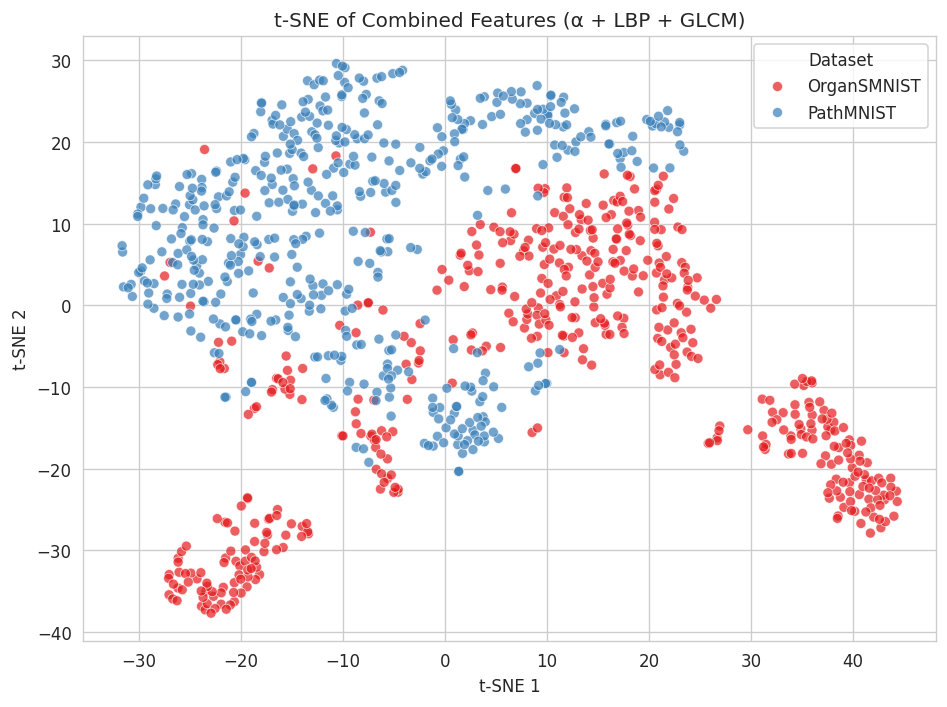

In [47]:
# ============================================================
# Exploratory: t-SNE (α + LBP + GLCM fusion features)
# ============================================================

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("\n==============================================")
print("t-SNE: Combined Feature Space (Fusion)")
print("==============================================")

# ------------------------------------------------------------
# SAFE feature builder
# ------------------------------------------------------------
def build_feature_vector(alpha, lbp, glcm):
    vec = np.concatenate([[alpha], lbp, glcm])
    vec = np.nan_to_num(vec)  # remove NaN/Inf safely
    return vec

# ------------------------------------------------------------
# Ensure grayscale GLCM exists for PathMNIST
# ------------------------------------------------------------
if 'path_glcm_gray' not in globals():
    print("Computing grayscale GLCM for PathMNIST (required for fair fusion)...")
    from skimage.color import rgb2gray
    path_gray = [rgb2gray(img) for img in path_imgs]
    path_glcm_gray = glcm_features(path_gray, is_rgb=False, colour_space='GRAY')

# ------------------------------------------------------------
# Build feature vectors
# ------------------------------------------------------------
organ_feats = [
    build_feature_vector(organ_alphas[i], organ_lbp[i], organ_glcm[i])
    for i in range(len(organ_imgs))
]

path_feats = [
    build_feature_vector(path_alphas[i], path_lbp[i], path_glcm_gray[i])
    for i in range(len(path_imgs))
]

# ------------------------------------------------------------
# Stack features
# ------------------------------------------------------------
X = np.vstack(organ_feats + path_feats)
y_labels = np.array(['OrganSMNIST']*len(organ_feats) + ['PathMNIST']*len(path_feats))

# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------
X = StandardScaler().fit_transform(X)

# ------------------------------------------------------------
# t-SNE
# ------------------------------------------------------------
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30,
    init='pca'
)

X_tsne = tsne.fit_transform(X)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_labels,
    palette='Set1',
    alpha=0.7,
    legend='full'
)

plt.title("t-SNE of Combined Features (α + LBP + GLCM)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


Feature Importance: α + LBP + GLCM (Fusion)

Feature group importance (normalised):
  Spectral slope (α): 0.100
  LBP features      : 0.296
  GLCM features     : 0.604


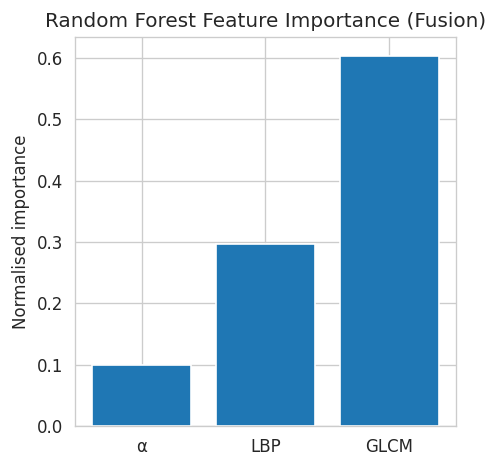

In [48]:
# ============================================================
# Exploratory: Random Forest Feature Importance (Fusion)
# ============================================================

print("\n==============================================")
print("Feature Importance: α + LBP + GLCM (Fusion)")
print("==============================================")

# ------------------------------------------------------------
# Ensure grayscale GLCM exists for PathMNIST
# ------------------------------------------------------------
if 'path_glcm_gray' not in globals():
    from skimage.color import rgb2gray
    path_gray = [rgb2gray(img) for img in path_imgs]
    path_glcm_gray = glcm_features(path_gray, is_rgb=False, colour_space='GRAY')

# ------------------------------------------------------------
# Build feature vectors (same dimensions for both datasets)
# ------------------------------------------------------------
def build_feature_vector(alpha, lbp_hist, glcm_vec):
    return np.concatenate([np.array([alpha]), lbp_hist, glcm_vec])

organ_feats = [build_feature_vector(organ_alphas[i], organ_lbp[i], organ_glcm[i]) for i in range(len(organ_imgs))]
path_feats = [build_feature_vector(path_alphas[i], path_lbp[i], path_glcm_gray[i]) for i in range(len(path_imgs))]

X = np.vstack(organ_feats + path_feats)
y = np.array(['Organ'] * len(organ_feats) + ['Path'] * len(path_feats))

# ------------------------------------------------------------
# Standardise and train Random Forest
# ------------------------------------------------------------
X_scaled = StandardScaler().fit_transform(X)

rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_scaled, y)

importances = rf.feature_importances_

n_alpha = 1
n_lbp = organ_lbp.shape[1]
n_glcm = organ_glcm.shape[1]

alpha_imp = importances[:n_alpha].mean()
lbp_imp = importances[n_alpha:n_alpha+n_lbp].mean()
glcm_imp = importances[n_alpha+n_lbp:].mean()
total = alpha_imp + lbp_imp + glcm_imp

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("\nFeature group importance (normalised):")
print(f"  Spectral slope (α): {alpha_imp/total:.3f}")
print(f"  LBP features      : {lbp_imp/total:.3f}")
print(f"  GLCM features     : {glcm_imp/total:.3f}")

# Optional: simple bar plot
plt.figure(figsize=(4,4))
plt.bar(['α', 'LBP', 'GLCM'], [alpha_imp/total, lbp_imp/total, glcm_imp/total])
plt.title("Random Forest Feature Importance (Fusion)")
plt.ylabel("Normalised importance")
plt.tight_layout()
plt.show()

**Exploratory Random Forest Feature Importance (Feature Fusion)**

A Random Forest classifier was trained on the concatenated feature representation comprising spectral slope α, multi‑scale LBP histograms, and grayscale GLCM features to distinguish OrganSMNIST from PathMNIST (1,000 samples; 500 per class). Feature importance values were aggregated at the descriptor‑family level and normalised to sum to 1.

**Results (normalised importance)**
- GLCM features: **0.604** (60.4%)
- LBP features: **0.296** (29.6%)
- Spectral slope α: **0.100** (10.0%)

**Interpretation**

GLCM features contribute the largest share of predictive importance, indicating that second‑order texture statistics (contrast, homogeneity, energy, and correlation) provide the strongest discriminative signal between CT‑derived anatomical images and histopathology patches. LBP features provide moderate discriminative power, reflecting the role of local micro‑patterns in distinguishing modality‑specific texture characteristics. In contrast, the spectral slope α contributes the least, suggesting that global frequency decay characteristics alone are relatively less informative for separating these two modalities.

This ordering is consistent with the nature of the descriptors: GLCM captures fine‑grained spatial co‑occurrence structure, which differs substantially between histopathology and CT imagery, whereas spectral slope α captures global scale‑invariant behaviour, which is relatively similar across both datasets (α ≈ 3.3), limiting its discriminative strength in a supervised setting.

**Summary (exploratory insight)**  
These results suggest that second‑order texture statistics are the most informative component of the proposed feature set for modality discrimination in this experimental setup, while local texture descriptors provide complementary information, and global spectral statistics contribute comparatively less discriminative power. It is important to note that these findings reflect classifier‑specific feature importance within a Random Forest model and should be interpreted as exploratory evidence rather than a general ranking of feature effectiveness.

## 7. Discussion & Architectural Implications

### Summary of Findings

- **H1 confirmed:** OrganSMNIST exhibits a significantly higher spectral slope (α) than PathMNIST (p < 1.19e-14, δ = 0.282, small), indicating faster power decay with frequency and smoother, more low‑frequency dominant structure.  
- **H2 not supported:** Contrary to expectation, OrganSMNIST shows higher GLCM contrast (δ = 0.270, small) and higher correlation (δ = 0.732, large), while homogeneity and energy are comparable between modalities. This suggests that second‑order texture differences are more nuanced than the original directional hypothesis assumed.  
- **H3 partially supported:** Correlation differs significantly across RGB channels (p = 7.91e-04, remains significant after Bonferroni), but contrast, homogeneity, and energy do not. Colour influences specific texture statistics (spatial dependency) but not all.  
- **H4 confirmed:** Spectral slope varies significantly across organ classes (p = 5.60e-24, η² ≈ 0.255, large effect), indicating class‑dependent frequency characteristics.  
- **H5 not supported:** PathMNIST shows marginally larger mean α drop under Gaussian noise (e.g., σ=0.05: Δα = 0.2827 vs 0.2652), suggesting slightly higher sensitivity, contrary to the hypothesis that OrganSMNIST would be more affected.

### Recommendations for Model Design

| Modality | Architectural Advice |
|----------|----------------------|
| **CT‑like (OrganSMNIST)** | Preserve high frequencies: use smaller strides, less aggressive pooling, or high‑pass skip connections. Denoising augmentations may help. |
| **Histopathology (PathMNIST)** | Colour is essential - use RGB input, consider stain normalisation. Multi‑scale texture modules (e.g., atrous convolution) are beneficial. |

### Limitations

- Original resolution 28×28 limits fine texture analysis; upsampling does not create new information.  
- Only two datasets - results may not generalise to all medical modalities (e.g., MRI, ultrasound).  
- Grayscale LBP discards colour texture; future work could use colour LBP variants.  
- Noise robustness tested on 100 images per dataset; larger samples may yield more stable estimates.

### Reproducibility

All code, random seeds (42), and MedMNIST version (3.0.2) are provided. Stratified sampling ensures balanced classes.

In [49]:
# ============================================================
# Runtime & completion
# ============================================================

end_time = time.time()
total_time = end_time - start_time

print("\n================================================")
print("EXECUTION COMPLETED")
print("================================================")

print(f"Total runtime: {total_time:.2f} seconds")

print("\nReproducibility metadata:")
print(f"- Seed: {SEED}")
print("- Dataset: MedMNIST (OrganSMNIST, PathMNIST)")
print("- Version: MedMNIST v3")
print("- Python: 3.12 (Colab runtime)")
print("- Analysis: FFT + LBP + GLCM + Statistical testing + ML models")

print("\nStatus: Notebook executed successfully with full feature extraction and analysis.")
print("All outputs are reproducible under fixed random seed (42).")


EXECUTION COMPLETED
Total runtime: 5184.36 seconds

Reproducibility metadata:
- Seed: 42
- Dataset: MedMNIST (OrganSMNIST, PathMNIST)
- Version: MedMNIST v3
- Python: 3.12 (Colab runtime)
- Analysis: FFT + LBP + GLCM + Statistical testing + ML models

Status: Notebook executed successfully with full feature extraction and analysis.
All outputs are reproducible under fixed random seed (42).
